In [34]:
import numpy as np
import scanpy as sc
import squidpy as sq
import stan


In [35]:
adata=sc.read_h5ad("data/Andersson2021/A1.h5ad")
sc.pp.filter_cells(adata, min_counts=100)
sc.pp.filter_genes(adata, min_cells=adata.n_obs/5)
sc.pp.normalize_total(adata)
adata.X=np.sqrt(adata.X)
sc.pp.scale(adata)
adata

AnnData object with n_obs × n_vars = 345 × 3886
    obs: 'Total Reads', 'pathology', 'sample', 'replicate', 'source', 'ER', 'HER2', 'PR', 'subtype', 'n_counts'
    var: 'n_cells', 'mean', 'std'
    uns: 'spatial'
    obsm: 'celltype_major', 'celltype_minor', 'celltype_subset', 'spatial', 'spatial_int'
    layers: 'counts', 'raw_counts'

/Users/aprilsagan/opt/anaconda3/lib/python3.8/site-packages/pandas/core/indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


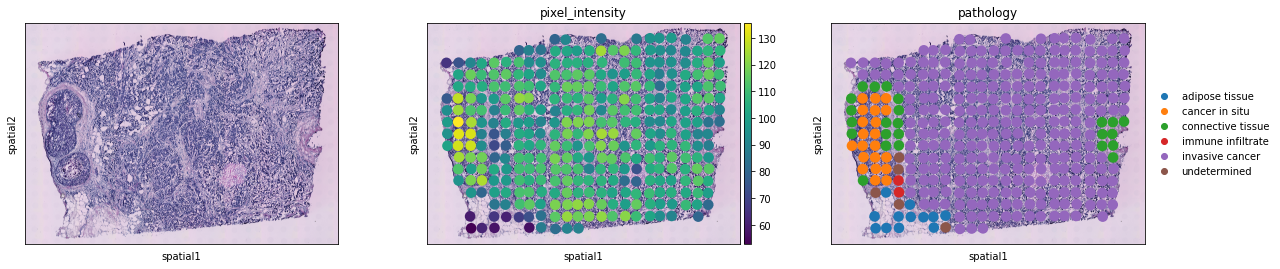

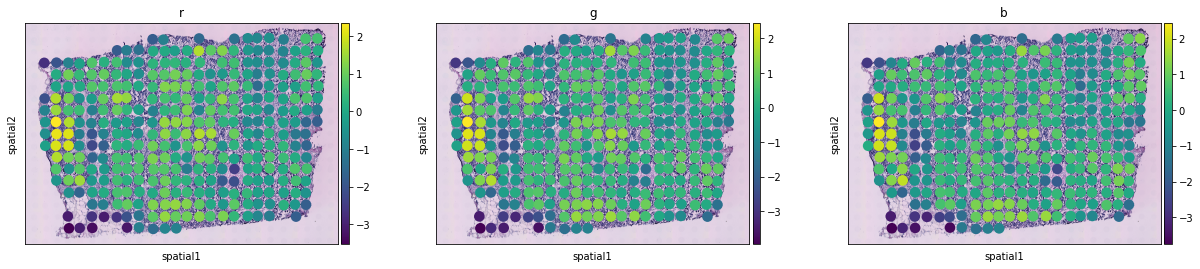

In [36]:
stan.pp.pixel_intensity(adata, window_size=130)
sc.pl.spatial(adata, color=[None, "pixel_intensity", 'pathology'], size=1.5)
sc.pl.spatial(sq.pl.extract(adata, obsm_key='pixel_intensity'), color=["r", "g", "b"], size=1.5)

In [37]:
genes_to_plot=adata.var.sort_values(by="std", ascending=False).head(4).index

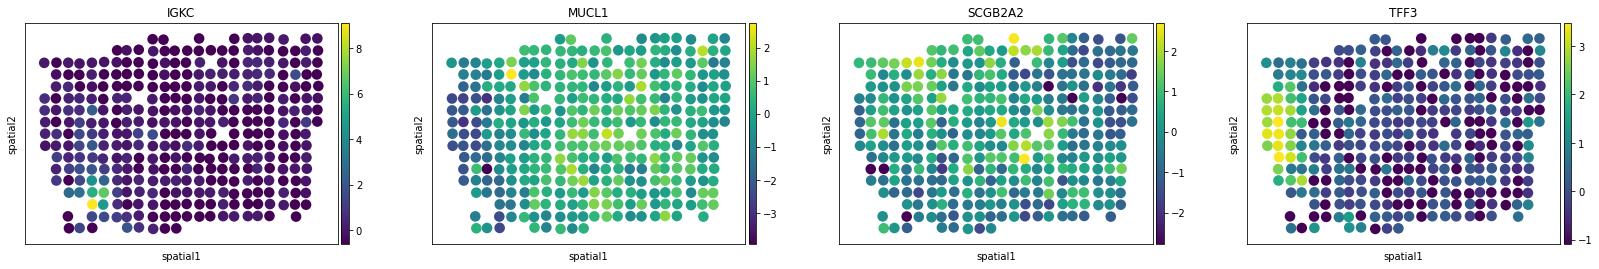

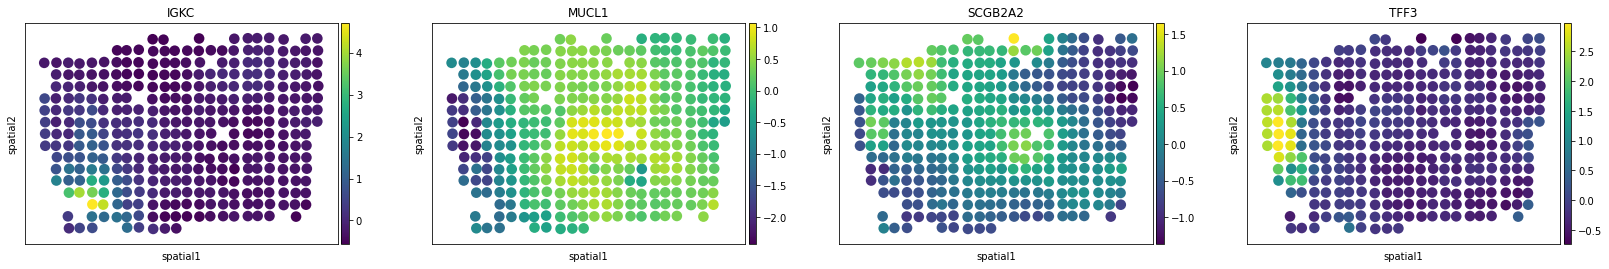

In [44]:
stan.pp.make_kernel(adata, n=200, im_feats_weight=0.15, banwidth=0.25)

adata.layers['spatial']=stan.pp.kernel_smooth(adata.to_df(), adata.obsp['kernel'])

sc.pl.spatial(adata, color=genes_to_plot, alpha_img=0, size=1.5)
sc.pl.spatial(adata, color=genes_to_plot, layer='spatial', alpha_img=0, size=1.5)

adata.var['spat_cor']=np.diag(adata.to_df('spatial').T.dot(adata.to_df())/adata.n_obs)

adata.to_df('spatial')

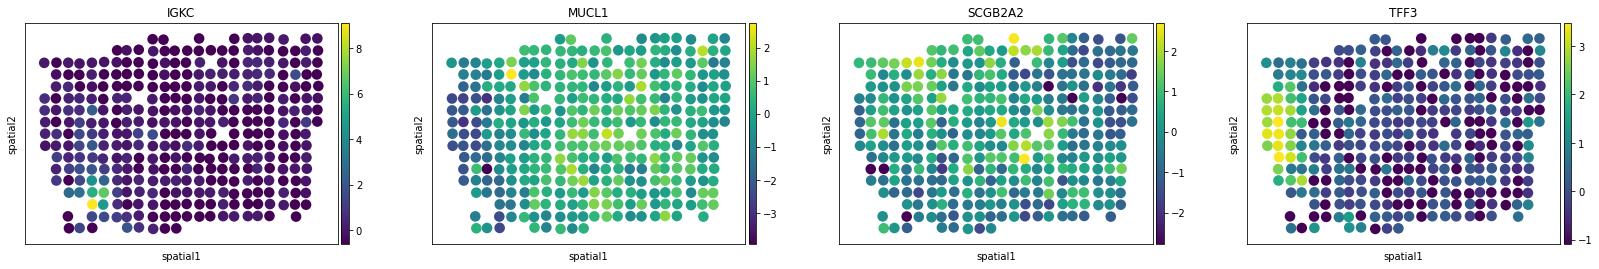

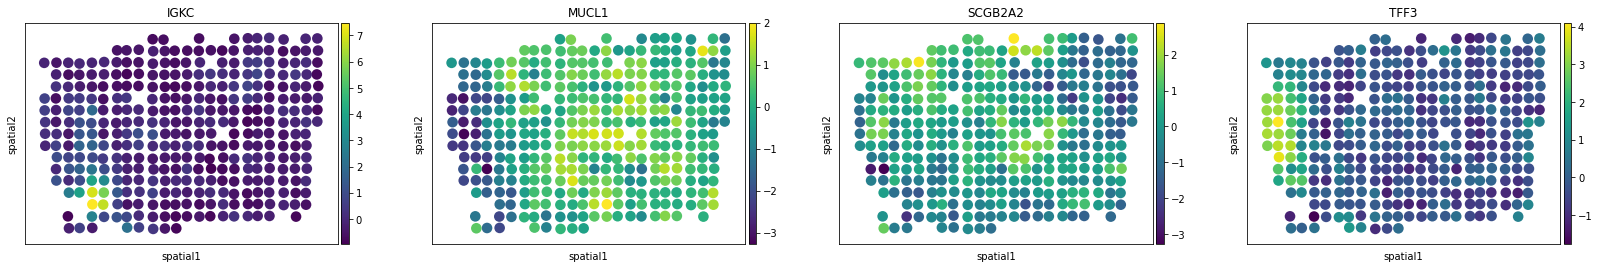

0.7710858757576668


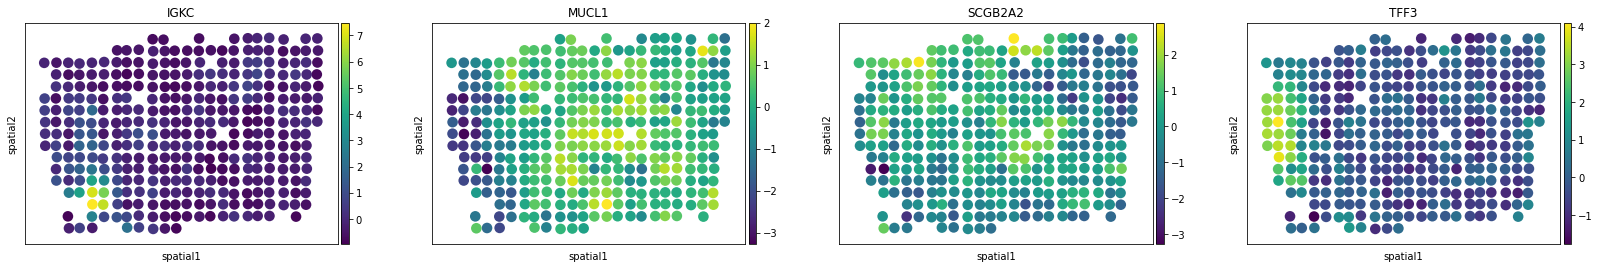

0.7710858757576668

In [45]:

Y=adata.to_df()
X=adata.obsm['kernel']

s=((X**2).sum(axis=0))
kernel_proj=X.dot(np.diag(s/(s**2 + 0)).dot(X.T))

adata.layers['spatial']=kernel_proj.dot(Y)
x=adata.layers['spatial'].T
x=(x-x.mean(axis=1).reshape(-1,1))/x.std(axis=1).reshape(-1,1)
adata.layers['spatial']=x.T
adata.var['approx_kernel_spat_cor']=np.diag(adata.to_df('spatial').T.dot(adata.to_df())/adata.n_obs)
sc.pl.spatial(adata, color=genes_to_plot, alpha_img=0, size=1.5)
sc.pl.spatial(adata, color=genes_to_plot, layer='spatial', alpha_img=0, size=1.5)
print(adata.var['approx_kernel_spat_cor'].median())

kernel_proj=X.dot(np.diag(s/(s**2 + 100)).dot(X.T))
adata.var['approx_kernel_spat_cor']=np.diag(adata.to_df('spatial').T.dot(adata.to_df())/adata.n_obs)
sc.pl.spatial(adata, color=genes_to_plot, layer='spatial', alpha_img=0, size=1.5)
adata.var['approx_kernel_spat_cor'].median()

In [46]:
adata.uns['spatial']['A1']['scalefactors']['spot_diameter_fullres']

{'images': {'hires': array([[[226, 211, 230],
          [226, 211, 230],
          [226, 211, 230],
          ...,
          [222, 209, 226],
          [222, 209, 226],
          [222, 209, 226]],
  
         [[226, 211, 230],
          [226, 211, 230],
          [226, 211, 230],
          ...,
          [222, 209, 226],
          [222, 209, 226],
          [222, 209, 226]],
  
         [[226, 211, 230],
          [226, 211, 230],
          [226, 211, 230],
          ...,
          [222, 209, 226],
          [222, 209, 226],
          [222, 209, 226]],
  
         ...,
  
         [[226, 212, 229],
          [226, 212, 229],
          [226, 212, 229],
          ...,
          [215, 207, 222],
          [220, 212, 227],
          [220, 212, 227]],
  
         [[226, 212, 229],
          [226, 212, 229],
          [226, 212, 229],
          ...,
          [218, 210, 225],
          [217, 209, 224],
          [216, 208, 223]],
  
         [[226, 212, 229],
          [226, 212, 229],
     